In [1]:
# Clean garbled characters and negative values
import pandas as pd
import re

# --- Configuration Section ---
input_file = 'srcsc-2026-claims-equipment-failure.xlsx'
output_file = 'cleaned_equipment_failure_data.xlsx'

def clean_dataframe(df):
    # Clean _???+digits from text
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].apply(lambda x: re.split(r'_\?\?\?', str(x))[0] if pd.notnull(x) else x)

    # absolute value
    num_cols = df.select_dtypes(include=['number']).columns
    df[num_cols] = df[num_cols].abs()
    return df

try:
    print("Reading data...")
    all_sheets = pd.read_excel(input_file, sheet_name=None)
    cleaned_sheets = {}
    
    for sheet_name, df in all_sheets.items():
        print(f"Cleaning sheet: {sheet_name}...")
        cleaned_sheets[sheet_name] = clean_dataframe(df)
    print(f"Saving cleaned data to {output_file}...")
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        for sheet_name, df in cleaned_sheets.items():
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            
    print("Task completed!")

except FileNotFoundError:
    print(f"Error: The file '{input_file}' was not found. Please check the filename.")
except Exception as e:
    print(f"An error occurred: {e}")

Reading data...
Cleaning sheet: freq...
Cleaning sheet: sev...
Saving cleaned data to cleaned_equipment_failure_data.xlsx...
Task completed!


In [3]:
# Compare whether data between two tables is consistent
import pandas as pd
import re

file_path = 'cleaned_equipment_failure_data.xlsx'
output_diff_file = 'data_discrepancy_report.xlsx'

def pre_clean(df):
    df = df.copy()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].apply(lambda x: re.split(r'_\?\?\?', str(x))[0] if pd.notnull(x) else x)
    num_cols = df.select_dtypes(include=['number']).columns
    df[num_cols] = df[num_cols].abs().round(4)
    return df

try:
    df_freq = pd.read_excel(file_path, sheet_name=0) # Assume the first sheet is freq
    df_sev = pd.read_excel(file_path, sheet_name=1)  # Assume the second sheet is sev

    df_freq = pre_clean(df_freq)
    df_sev = pre_clean(df_sev)
    cols_to_compare = ['equipment_type', 'equipment_age', 'solar_system', 'maintenance_int', 'usage_int', 'exposure']
    keys = ['policy_id', 'equipment_id']

    merged = pd.merge(df_freq, df_sev, on=keys, suffixes=('_freq', '_sev'))
    is_different = pd.Series(False, index=merged.index)
    
    for col in cols_to_compare:
        col_freq = f"{col}_freq"
        col_sev = f"{col}_sev"
        diff_in_col = (merged[col_freq] != merged[col_sev]) & ~(merged[col_freq].isna() & merged[col_sev].isna())
        is_different = is_different | diff_in_col
    diff_report = merged[is_different].copy()
    
    diff_count = diff_report.shape[0]
    print(f"--- Check Completed ---")
    print(f"Out of {len(merged)} common records, found a total of {diff_count} inconsistent records.")

    if diff_count > 0:
        output_cols = keys + [c for col in cols_to_compare for c in (f"{col}_freq", f"{col}_sev")]
        diff_report[output_cols].to_excel(output_diff_file, index=False)
        print(f"Discrepancy report saved to: {output_diff_file}")
    else:
        print("Data in both tables is perfectly consistent. No discrepancy file generated.")

except Exception as e:
    print(f"An error occurred during processing: {e}")

--- Check Completed ---
Out of 8189 common records, found a total of 239 inconsistent records.
Discrepancy report saved to: data_discrepancy_report.xlsx


In [5]:
# Check the range of each variable
import pandas as pd

file_path = 'cleaned_equipment_failure_data.xlsx'

def analyze_sheet(df, sheet_name):
    print(f"\n{'='*20} Worksheet: {sheet_name} Analysis Report {'='*20}")
    
    # Count rows containing blank 
    rows_with_nan = df.isnull().any(axis=1).sum()
    print(f"-> Number of rows with blank cells: {rows_with_nan}")
    print("\n[Numerical Column Ranges]")
    num_df = df.select_dtypes(include=['number'])
    if not num_df.empty:
        stats = num_df.describe().loc[['min', 'max']].T
        stats.columns = ['Min', 'Max']
        print(stats)
    else:
        print("No numerical columns found")

    print("\n[Text Column Category Statistics]")
    obj_df = df.select_dtypes(include=['object'])
    if not obj_df.empty:
        for col in obj_df.columns:
            print(f"- Column Name: {col}")
            counts = df[col].value_counts(dropna=False)
            print(counts)
            print("-" * 30)
    else:
        print("No text columns found")

try:
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    for name, df in all_sheets.items():
        analyze_sheet(df, name)

except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please ensure the previous cleaning script ran successfully.")
except Exception as e:
    print(f"An error occurred during analysis: {e}")


==================== Worksheet: freq Analysis Report ====================
-> Number of rows with blank cells: 1641

[Numerical Column Ranges]
                     Min           Max
equipment_age      3.000    327.359193
maintenance_int  100.010  31866.243478
usage_int          0.000    467.893352
exposure           0.083     15.694195
claim_count        0.000     32.294355

[Text Column Category Statistics]
- Column Name: policy_id
policy_id
NaN          224
EF-973739      4
EF-488780      4
EF-073633      4
EF-765198      3
            ... 
EF-823825      1
EF-585624      1
EF-412042      1
EF-748235      1
EF-913200      1
Name: count, Length: 90535, dtype: int64
------------------------------
- Column Name: equipment_id
equipment_id
NaN          221
EQ-908110      4
EQ-284792      4
EQ-577624      3
EQ-537298      3
            ... 
EQ-668258      1
EQ-659317      1
EQ-005663      1
EQ-681473      1
EQ-889397      1
Name: count, Length: 90469, dtype: int64
-------------------------

In [31]:
# Count the number of abnormal data points for each variable
import pandas as pd

# Official ranges
official_ranges = {
    'equipment_age': (3, 25),
    'maintenance_int': (100, 2000),
    'usage_int': (0, 100),
    'exposure': (0, 1)
}

def check_out_of_bounds(df, sheet_name):
    print(f"\n{'='*25} {sheet_name} Outlier Statistics {'='*25}")
    results = []
    
    for col, (min_val, max_val) in official_ranges.items():
        if col in df.columns:
            under_min = (df[col] < min_val).sum()
            over_max = (df[col] > max_val).sum()
            total_out = under_min + over_max
            pct_out = (total_out / len(df)) * 100
            actual_min = df[col].min()
            actual_max = df[col].max()
            
            results.append({
                'Variable': col,
                'Defined Range': f"[{min_val}, {max_val}]",
                'Actual Min': round(actual_min, 2) if pd.notnull(actual_min) else "N/A",
                'Actual Max': round(actual_max, 2) if pd.notnull(actual_max) else "N/A",
                'Out of Bounds (Count)': total_out,
                'Out of Bounds (%)': f"{pct_out:.2f}%"
            })
    
    res_df = pd.DataFrame(results)
    if not res_df.empty:
        print(res_df.to_string(index=False))
    else:
        print("No variable columns found for statistics.")

try:
    file_path = 'cleaned_equipment_failure_data.xlsx'
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    
    for name, df in all_sheets.items():
        check_out_of_bounds(df, name)
    print("\n" + "="*65)


except FileNotFoundError:
    print(f"Error: File {file_path} not found")
except Exception as e:
    print(f"Statistics error: {e}")


========================= freq Outlier Statistics =========================
       Variable Defined Range  Actual Min  Actual Max  Out of Bounds (Count) Out of Bounds (%)
  equipment_age       [3, 25]        3.00      327.36                    269             0.28%
maintenance_int   [100, 2000]      100.01   31,866.24                    152             0.16%
      usage_int      [0, 100]        0.00      467.89                     94             0.10%
       exposure        [0, 1]        0.08       15.69                    138             0.15%

========================= sev Outlier Statistics =========================
       Variable Defined Range  Actual Min  Actual Max  Out of Bounds (Count) Out of Bounds (%)
  equipment_age       [3, 25]        3.00      269.24                     46             0.56%
maintenance_int   [100, 2000]      100.01   21,980.46                      7             0.08%
      usage_int      [0, 100]        0.01      405.08                      8           

In [9]:
# Delete rows with blanks and apply capping to all outlier values
import pandas as pd

official_ranges = {
    'equipment_age': (3, 25),
    'maintenance_int': (100, 2000),
    'usage_int': (0, 100),
    'exposure': (0, 1)
}

input_file = 'cleaned_equipment_failure_data.xlsx'
output_file = 'final_cleaned_equipment_data.xlsx'

def second_cleaning_step(df, ranges):
    # Delete rows containing any missing
    initial_count = len(df)
    df_clean = df.dropna().copy()
    dropped_count = initial_count - len(df_clean)
    
    # Apply Capping
    for col, (min_val, max_val) in ranges.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].clip(lower=min_val, upper=max_val)
            
    return df_clean, dropped_count

try:
    print(f"Reading {input_file}...")
    all_sheets = pd.read_excel(input_file, sheet_name=None)
    
    final_sheets = {}
    total_dropped = 0
    
    for sheet_name, df in all_sheets.items():
        print(f"Performing deep cleaning on worksheet [{sheet_name}]...")
        cleaned_df, dropped = second_cleaning_step(df, official_ranges)
        final_sheets[sheet_name] = cleaned_df
        total_dropped += dropped
        print(f" - Rows with null values deleted: {dropped}")
        print(f" - Capping completed for variables: {list(official_ranges.keys())}")

    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        for sheet_name, df in final_sheets.items():
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    print("-" * 30)
    print(f"All tasks completed!")
    print(f"Final cleaned data saved to: {output_file}")
    print(f"Total rows with null values deleted across all sheets: {total_dropped}")

except Exception as e:
    print(f"An error occurred during processing: {e}")

Reading cleaned_equipment_failure_data.xlsx...
Performing deep cleaning on worksheet [freq]...
 - Rows with null values deleted: 1641
 - Capping completed for variables: ['equipment_age', 'maintenance_int', 'usage_int', 'exposure']
Performing deep cleaning on worksheet [sev]...
 - Rows with null values deleted: 186
 - Capping completed for variables: ['equipment_age', 'maintenance_int', 'usage_int', 'exposure']
------------------------------
All tasks completed!
Final cleaned data saved to: final_cleaned_equipment_data.xlsx
Total rows with null values deleted across all sheets: 1827


In [11]:
# Data distribution visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

input_file = 'final_cleaned_equipment_data.xlsx'
output_dir = 'eda_plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def plot_distributions(df, sheet_name):
    print(f"Generating plots for sheet: {sheet_name}...")
    cols = [c for c in df.columns if 'id' not in c.lower()]
    
    for col in cols:
        plt.figure()
        if pd.api.types.is_numeric_dtype(df[col]):
            # Numerical variable: Use Histogram + Kernel Density Estimate (KDE)
            sns.histplot(df[col], kde=True, color='skyblue', bins=30)
            plt.title(f'Distribution of {col} ({sheet_name})', fontsize=15)
            plt.xlabel(col)
            plt.ylabel('Frequency')
        else:
            order = df[col].value_counts().index
            sns.countplot(data=df, x=col, order=order, palette='viridis')
            plt.title(f'Frequency of {col} ({sheet_name})', fontsize=15)
            plt.xticks(rotation=45)
            plt.xlabel(col)
            plt.ylabel('Count')

        file_name = f"{sheet_name}_{col}_distribution.png"
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, file_name))
        plt.close()  

try:
    all_sheets = pd.read_excel(input_file, sheet_name=None)
    for name, df in all_sheets.items():
        plot_distributions(df, name)
    print(f"\n[Success] All plots have been saved in the '{output_dir}' folder.")

except Exception as e:
    print(f"Error during plotting: {e}")

Generating plots for sheet: freq...


C:\Users\12977\AppData\Local\Temp\ipykernel_35284\2863954147.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\12977\AppData\Local\Temp\ipykernel_35284\2863954147.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')


Generating plots for sheet: sev...


C:\Users\12977\AppData\Local\Temp\ipykernel_35284\2863954147.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\12977\AppData\Local\Temp\ipykernel_35284\2863954147.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')



[Success] All plots have been saved in the 'eda_plots' folder.


In [12]:
# Numerical display of specific data distributions
import pandas as pd

official_ranges = {
    'equipment_age': '3 - 25',
    'maintenance_int': '100 - 2000',
    'usage_int': '0 - 100',
    'exposure': '0 - 1'
}

input_file = 'final_cleaned_equipment_data.xlsx'

try:
    all_sheets = pd.read_excel(input_file, sheet_name=None)
    
    for sheet_name, df in all_sheets.items():
        print(f"\n{'='*30} Statistics for: {sheet_name} {'='*30}")
        num_df = df.select_dtypes(include=['number'])
        if not num_df.empty:
            # Get basic statistics
            stats = num_df.describe(percentiles=[.25, .5, .75]).T
            stats['Defined Range'] = stats.index.map(lambda x: official_ranges.get(x, "N/A"))
            cols_order = ['count', 'mean', 'min', '25%', '50%', '75%', 'max', 'Defined Range']
            existing_cols = [c for c in cols_order if c in stats.columns]
            
            print("\n[Numerical Variables]")
            print(stats[existing_cols].to_string())
        cat_df = df.select_dtypes(exclude=['number'])
        cat_cols = [c for c in cat_df.columns if 'id' not in c.lower()]
        
        if cat_cols:
            print("\n[Categorical Variables (Top Categories)]")
            for col in cat_cols:
                top_info = df[col].value_counts().head(3)
                print(f"- {col}: Total Categories = {df[col].nunique()}")
                for cat, count in top_info.items():
                    print(f"  * {cat}: {count} records")
except Exception as e:
    print(f"An error occurred: {e}")


============================== Statistics for: freq ==============================

[Numerical Variables]
                   count        mean      min      25%      50%       75%          max Defined Range
equipment_age    93421.0   10.208910    3.000    6.646   10.000    13.396    25.000000        3 - 25
maintenance_int  93421.0  953.261089  100.010  528.590  951.700  1379.160  2000.000000    100 - 2000
usage_int        93421.0   12.117688    0.000    6.050   12.020    18.000   100.000000       0 - 100
exposure         93421.0    0.500387    0.083    0.326    0.499     0.674     1.000000         0 - 1
claim_count      93421.0    0.080512    0.000    0.000    0.000     0.000    32.294355           N/A

[Categorical Variables (Top Categories)]
- equipment_type: Total Categories = 6
  * ReglAggregators: 26610 records
  * Quantum Bore: 22102 records
  * Ion Pulverizer: 17838 records
- solar_system: Total Categories = 3
  * Epsilon: 37345 records
  * Zeta: 37271 records
  * Helionis Clus

--- Basic Statistics ---
               Variable         Mean     Variance
Claim Count (Frequency)     0.080512 1.218917e-01
Claim Amount (Severity) 89579.952484 9.520750e+09
------------------------------


C:\Users\12977\AppData\Local\Temp\ipykernel_35284\1009699839.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='claim_count', data=df_freq, ax=axes[0, 0], palette='viridis')


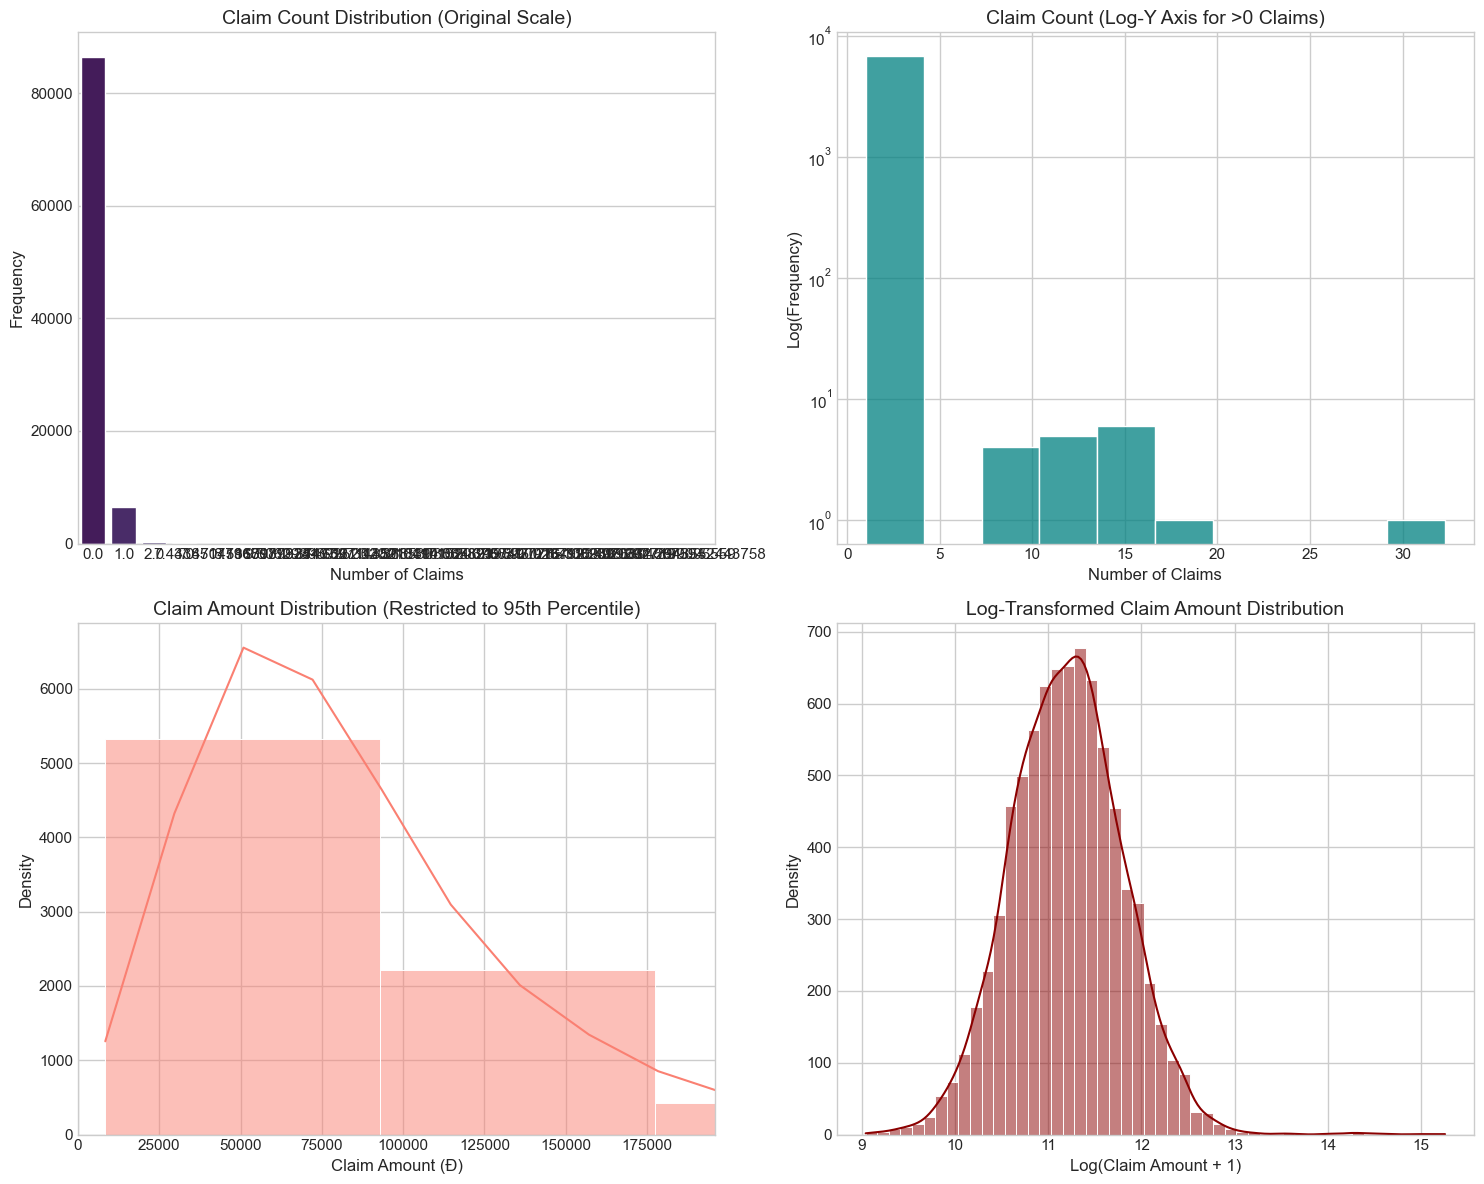

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = 'final_cleaned_equipment_data.xlsx'
df_freq = pd.read_excel(file_path, sheet_name='freq')
df_sev = pd.read_excel(file_path, sheet_name='sev')

stats_data = {
    "Variable": ["Claim Count (Frequency)", "Claim Amount (Severity)"],
    "Mean": [df_freq['claim_count'].mean(), df_sev['claim_amount'].mean()],
    "Variance": [df_freq['claim_count'].var(), df_sev['claim_amount'].var()]
}
stats_df = pd.DataFrame(stats_data)

print("--- Basic Statistics ---")
print(stats_df.to_string(index=False))
print("-" * 30)

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Claim Count Distribution (Normal)
sns.countplot(x='claim_count', data=df_freq, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Claim Count Distribution (Original Scale)', fontsize=14)
axes[0, 0].set_xlabel('Number of Claims')
axes[0, 0].set_ylabel('Frequency')

#Claim Count Distribution (Log Scale) 
sns.histplot(df_freq[df_freq['claim_count'] > 0]['claim_count'], kde=False, ax=axes[0, 1], bins=10, color='teal')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Claim Count (Log-Y Axis for >0 Claims)', fontsize=14)
axes[0, 1].set_xlabel('Number of Claims')
axes[0, 1].set_ylabel('Log(Frequency)')


# Narrow the X-axis range to show the main distribution, filtering out extreme tail outliers
upper_limit = df_sev['claim_amount'].quantile(0.95) # Use 95th percentile as the display upper bound
sns.histplot(df_sev['claim_amount'], bins=50, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_xlim(0, upper_limit) 
axes[1, 0].set_title(f'Claim Amount Distribution (Restricted to 95th Percentile)', fontsize=14)
axes[1, 0].set_xlabel('Claim Amount (Đ)')
axes[1, 0].set_ylabel('Density')

sns.histplot(np.log1p(df_sev['claim_amount']), bins=50, kde=True, ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('Log-Transformed Claim Amount Distribution', fontsize=14)
axes[1, 1].set_xlabel('Log(Claim Amount + 1)')
axes[1, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

--- Claim Amount Outlier Analysis ---
Upper Bound: 197,906.75 Đ
Detected 391 outlier claim records
Outlier Percentage: 4.84%

--- Claim Count Outlier Analysis ---
Detected 392 high-frequency claim records (Exceeding 3 Standard Deviations)


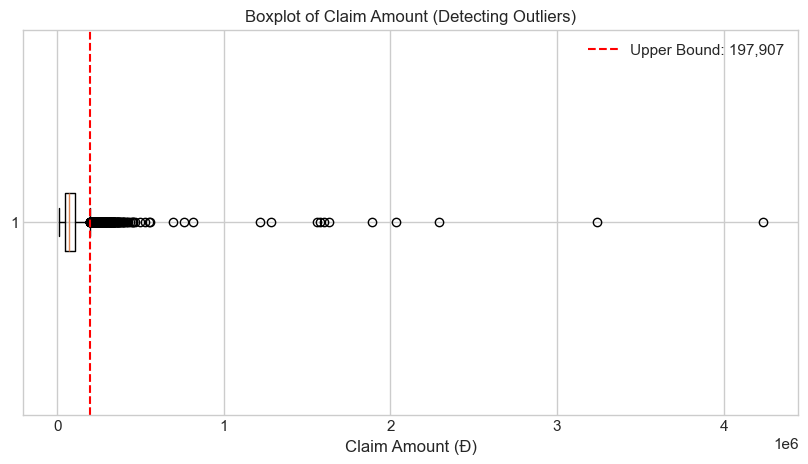

In [17]:
import pandas as pd
import numpy as np

file_path = 'final_cleaned_equipment_data.xlsx'
df_freq = pd.read_excel(file_path, sheet_name='freq')
df_sev = pd.read_excel(file_path, sheet_name='sev')

def get_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_amount, low_amt, up_amt = get_outliers_iqr(df_sev, 'claim_amount')
print(f"--- Claim Amount Outlier Analysis ---")
print(f"Upper Bound: {up_amt:,.2f} Đ")
print(f"Detected {len(outliers_amount)} outlier claim records")
print(f"Outlier Percentage: {(len(outliers_amount)/len(df_sev))*100:.2f}%")

mean_count = df_freq['claim_count'].mean()
std_count = df_freq['claim_count'].std()
outliers_count = df_freq[(df_freq['claim_count'] > mean_count + 3 * std_count)]
print(f"\n--- Claim Count Outlier Analysis ---")
print(f"Detected {len(outliers_count)} high-frequency claim records (Exceeding 3 Standard Deviations)")

plt.figure(figsize=(10, 5))
plt.boxplot(df_sev['claim_amount'], vert=False)
plt.title('Boxplot of Claim Amount (Detecting Outliers)')
plt.xlabel('Claim Amount (Đ)')
plt.axvline(up_amt, color='red', linestyle='--', label=f'Upper Bound: {up_amt:,.0f}')
plt.legend()
plt.show()

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import genpareto
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

file_path = 'final_cleaned_equipment_data.xlsx'
df_freq_raw = pd.read_excel(file_path, sheet_name='freq')
df_sev_raw = pd.read_excel(file_path, sheet_name='sev')

def bin_age(age):
    if age < 5: return '<5'
    elif age < 10: return '5-9'
    elif age < 15: return '10-14'
    elif age < 20: return '15-19'
    else: return '20+'


for df in [df_freq_raw, df_sev_raw]:
    df['age_bin'] = df['equipment_age'].apply(bin_age)
    if 'claim_count' in df.columns:
        df['has_claim'] = (df['claim_count'] > 0).astype(int)
    df['log_exposure'] = np.log(df['exposure'].clip(lower=1e-5))

scaler = StandardScaler()
cols_to_scale = ['usage_int', 'maintenance_int']
df_freq_raw[[f'{c}_std' for c in cols_to_scale]] = scaler.fit_transform(df_freq_raw[cols_to_scale])
df_sev_raw[[f'{c}_std' for c in cols_to_scale]] = scaler.transform(df_sev_raw[cols_to_scale])


# Frequency Model
print("\n" + "="*30 + " Frequency Model Step 1: Logit " + "="*30)
logit_formula = "has_claim ~ C(equipment_type) + C(age_bin) + usage_int_std + maintenance_int_std + C(solar_system) + log_exposure"
logit_model = smf.logit(logit_formula, data=df_freq_raw).fit(disp=False)
print(logit_model.summary())

df_pos = df_freq_raw[df_freq_raw['claim_count'] > 0].copy()
empirical_mean_intensity = df_pos['claim_count'].mean()
print(f"Empirical Mean Intensity: {empirical_mean_intensity:.4f}")

# Severity Model
THRESHOLD = 197906
df_body = df_sev_raw[df_sev_raw['claim_amount'] <= THRESHOLD].copy()
df_tail = df_sev_raw[df_sev_raw['claim_amount'] > THRESHOLD].copy()

print("\n" + "="*30 + " Severity Model: Gamma Body " + "="*30)
body_formula = "claim_amount ~ C(equipment_type) + C(age_bin) + usage_int_std + C(solar_system) + log_exposure"
body_model = smf.glm(
    body_formula,
    data=df_body, family=sm.families.Gamma(link=sm.families.links.Log())
).fit()
print(body_model.summary())

excess_loss = df_tail['claim_amount'] - THRESHOLD
shape, loc, scale_gpd = genpareto.fit(excess_loss)
print(f"GPD Parameter Fit Results: Shape(xi)={shape:.4f}, Scale(sigma)={scale_gpd:.2f}")

print("\n" + "="*30 + " Executing Heterogeneous Aggregate Loss Simulation (10,000 Paths) " + "="*30)
np.random.seed(42)
N_SIMS = 10000

gamma_phi = body_model.scale
tail_prob = len(df_tail) / len(df_sev_raw)

def simulate_portfolio_loss_heterogeneous(usage_multiplier=1.0):
    df_test = df_freq_raw.copy()
    if usage_multiplier != 1.0:
        df_test['usage_int_std'] *= usage_multiplier
    prob_claim = logit_model.predict(df_test) 
    lambda_vec = prob_claim * empirical_mean_intensity
    expected_n_total = lambda_vec.sum()
    p_claim_source = lambda_vec / expected_n_total
    mu_vec = body_model.predict(df_test).values
    
    losses = []
    for _ in range(N_SIMS):
        n_claims = np.random.poisson(expected_n_total)
        
        if n_claims > 0:
            n_tail = np.random.binomial(n=n_claims, p=tail_prob)
            n_body = n_claims - n_tail

            if n_body > 0:
                sampled_mus = np.random.choice(mu_vec, size=n_body, p=p_claim_source)
                body_samples = np.random.gamma(shape=1/gamma_phi, scale=sampled_mus*gamma_phi)
                body_sum = np.sum(body_samples)
            else:
                body_sum = 0
        
            if n_tail > 0:
                tail_samples = THRESHOLD + genpareto.rvs(shape, loc, scale_gpd, size=n_tail)
                tail_sum = np.sum(tail_samples)
            else:
                tail_sum = 0
                
            losses.append(body_sum + tail_sum)
        else:
            losses.append(0)
            
    return np.array(losses)

base_losses = simulate_portfolio_loss_heterogeneous(usage_multiplier=1.0)
stress_losses = simulate_portfolio_loss_heterogeneous(usage_multiplier=1.2) 

var_99_base = np.percentile(base_losses, 99)
tvar_99_base = base_losses[base_losses >= var_99_base].mean()
expected_loss_base = base_losses.mean()
economic_capital = var_99_base - expected_loss_base

var_99_stress = np.percentile(stress_losses, 99)
stress_impact = var_99_stress - var_99_base

print("\n" + "="*35 + " Final Actuarial Evaluation Report " + "="*35)
print(f"【Base Case】")
print(f"Expected Annual Total Loss (Pure Premium) : {expected_loss_base:,.0f} Đ")
print(f"99% Value at Risk (VaR 99%)                : {var_99_base:,.0f} Đ")
print(f"99% Tail Value at Risk (TVaR 99%)          : {tvar_99_base:,.0f} Đ")
print(f"Recommended Economic Capital              : {economic_capital:,.0f} Đ")
print("-" * 80)
print(f"【Stress Test Scenario (Usage +20%)】")
print(f"Stress Scenario VaR 99%                   : {var_99_stress:,.0f} Đ")
print(f"Additional Capital Requirement (Buffer)   : +{stress_impact:,.0f} Đ")
print("="*88)


============================== Frequency Model Step 1: Logit ==============================
                           Logit Regression Results                           
Dep. Variable:              has_claim   No. Observations:                93421
Model:                          Logit   Df Residuals:                    93406
Method:                           MLE   Df Model:                           14
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                 0.05902
Time:                        17:29:08   Log-Likelihood:                -23174.
converged:                       True   LL-Null:                       -24627.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -1.3384      0.0

In [20]:
import pandas as pd
import numpy as np

file_path = 'final_cleaned_equipment_data.xlsx'
df_sev_raw = pd.read_excel(file_path, sheet_name='sev')

THRESHOLD = 197906

df_filtered = df_sev_raw[df_sev_raw['claim_amount'] > THRESHOLD].copy()

stats = df_filtered.groupby('equipment_type')['claim_amount'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Variance', 'var'),
    ('Q0_Min', 'min'),
    ('Q25', lambda x: x.quantile(0.25)),
    ('Q50_Median', 'median'),
    ('Q75', lambda x: x.quantile(0.75)),
    ('Q100_Max', 'max')
])

pd.set_option('display.float_format', '{:,.2f}'.format)
print(f"=== Risk Statistical Analysis for Claims Exceeding {THRESHOLD:,} ===")
print(stats)
print("\n=== Detailed Distribution Profiles ===")
for eq_type in stats.index:
    subset = df_filtered[df_filtered['equipment_type'] == eq_type]['claim_amount']
    print(f"\nEquipment: {eq_type}")
    print(subset.describe(percentiles=[0.25, 0.5, 0.75]))

=== Risk Statistical Analysis for Claims Exceeding 197,906 ===
                    Count       Mean           Variance     Q0_Min        Q25  \
equipment_type                                                                  
FexStram Carrier        6 452,815.37  50,387,641,100.35 238,089.00 282,064.48   
Flux Rider              8 313,758.73  42,171,888,044.98 208,372.00 216,205.00   
Graviton Extractor     27 280,055.15  42,660,321,734.49 197,931.00 210,720.00   
Ion Pulverizer         49 307,948.66 121,043,034,756.58 200,154.00 210,220.00   
Quantum Bore          234 311,459.00 136,096,927,955.82 198,157.00 215,331.25   
ReglAggregators        67 308,872.27  82,681,613,151.31 198,888.00 222,974.00   

                    Q50_Median        Q75     Q100_Max  
equipment_type                                          
FexStram Carrier    386,022.49 619,952.17   761,417.72  
Flux Rider          241,824.50 274,061.50   814,462.83  
Graviton Extractor  227,097.00 248,774.00 1,282,636.17  
Ion

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import genpareto
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

file_path = 'final_cleaned_equipment_data.xlsx'
df_freq_raw = pd.read_excel(file_path, sheet_name='freq')
df_sev_raw = pd.read_excel(file_path, sheet_name='sev')

def bin_age(age):
    if age < 5: return '<5'
    elif age < 10: return '5-9'
    elif age < 15: return '10-14'
    elif age < 20: return '15-19'
    else: return '20+'

for df in [df_freq_raw, df_sev_raw]:
    df['age_bin'] = df['equipment_age'].apply(bin_age)
    if 'claim_count' in df.columns:
        df['has_claim'] = (df['claim_count'] > 0).astype(int)
    df['log_exposure'] = np.log(df['exposure'].clip(lower=1e-5))

scaler = StandardScaler()
cols_to_scale = ['usage_int', 'maintenance_int']
df_freq_raw[[f'{c}_std' for c in cols_to_scale]] = scaler.fit_transform(df_freq_raw[cols_to_scale])
df_sev_raw[[f'{c}_std' for c in cols_to_scale]] = scaler.transform(df_sev_raw[cols_to_scale])


THRESHOLD = 197906

equipment_types = df_freq_raw['equipment_type'].unique()

np.random.seed(42)
N_SIMS = 10000

for eq in equipment_types:
    
    print("\n" + "="*80)
    print(f"Equipment Type: {eq}")
    print("="*80)
    
    df_freq = df_freq_raw[df_freq_raw['equipment_type'] == eq].copy()
    df_sev = df_sev_raw[df_sev_raw['equipment_type'] == eq].copy()
    
    if len(df_freq) < 500:
        print("Insufficient data volume, skipping...")
        continue
    
    # --- Frequency Model Step 1: Logit ---
    logit_formula = "has_claim ~ C(age_bin) + usage_int_std + maintenance_int_std + C(solar_system) + log_exposure"
    
    try:
        logit_model = smf.logit(logit_formula, data=df_freq).fit(disp=False)
        print(logit_model.summary())
    except:
        print("Logit convergence failed, skipping this equipment type")
        continue
    

    df_pos = df_freq[df_freq['claim_count'] > 0]
    if len(df_pos) == 0:
        continue
    empirical_mean_intensity = df_pos['claim_count'].mean()
    print(f"Empirical Mean Intensity: {empirical_mean_intensity:.4f}")
    

    df_body = df_sev[df_sev['claim_amount'] <= THRESHOLD].copy()
    df_tail = df_sev[df_sev['claim_amount'] > THRESHOLD].copy()
    
    if len(df_body) < 200:
        print("Insufficient Body data, skipping...")
        continue


    current_tail_prob = len(df_tail) / len(df_sev) if len(df_sev) > 0 else 0
    
    sev_formula = "claim_amount ~ C(age_bin) + usage_int_std + C(solar_system) + log_exposure"
    
    try:
        body_model = smf.glm(
            sev_formula,
            data=df_body,
            family=sm.families.Gamma(link=sm.families.links.Log())
        ).fit()
        print(body_model.summary())
        
    except:
        print("Gamma model failed, skipping...")
        continue
    
    gamma_phi = body_model.scale
    

    if len(df_tail) > 5:  
        excess_loss = df_tail['claim_amount'] - THRESHOLD
        shape_local, loc_local, scale_gpd_local = genpareto.fit(excess_loss)
        print(f"GPD Fit Successful: Tail Prob={current_tail_prob:.4%}, Shape={shape_local:.4f}")
    else:
        current_tail_prob = 0
        shape_local, loc_local, scale_gpd_local = 0, 0, 0
        print("Insufficient tail data; tail loss will not be simulated for this equipment")
    
    def simulate_loss(df_input, usage_multiplier=1.0):
        
        df_test = df_input.copy()
        df_test['usage_int_std'] *= usage_multiplier
        
        prob_claim = logit_model.predict(df_test)
        lambda_vec = prob_claim * empirical_mean_intensity
        expected_n = lambda_vec.sum()
        
        if expected_n <= 0:
            return np.zeros(N_SIMS)
        
        p_source = lambda_vec / expected_n
        mu_vec = body_model.predict(df_test).values
        
        losses = []
        for _ in range(N_SIMS):
            n_claims = np.random.poisson(expected_n)
            
            if n_claims > 0:
                n_tail = np.random.binomial(n_claims, current_tail_prob)
                n_body = n_claims - n_tail
                
                if n_body > 0:
                    sampled_mu = np.random.choice(mu_vec, size=n_body, p=p_source)
                    body_samples = np.random.gamma(
                        shape=1/gamma_phi,
                        scale=sampled_mu * gamma_phi
                    )
                    body_sum = body_samples.sum()
                else:
                    body_sum = 0
                
                if n_tail > 0:
                    tail_samples = THRESHOLD + genpareto.rvs(
                        shape_local, loc_local, scale_gpd_local, size=n_tail
                    )
                    tail_sum = tail_samples.sum()
                else:
                    tail_sum = 0
                
                losses.append(body_sum + tail_sum)
            else:
                losses.append(0)
        
        return np.array(losses)
    
    base_losses = simulate_loss(df_freq, 1.0)
    stress_losses = simulate_loss(df_freq, 1.2)
    
    var_99 = np.percentile(base_losses, 99)
    tvar_99 = base_losses[base_losses >= var_99].mean() if any(base_losses >= var_99) else var_99
    mean_loss = base_losses.mean()
    econ_cap = var_99 - mean_loss
    var_stress = np.percentile(stress_losses, 99)
    
    print(f"\n--- [{eq}] Risk Assessment Report ---")
    print(f"Expected Loss     : {mean_loss:,.0f}")
    print(f"VaR 99%           : {var_99:,.0f}")
    print(f"TVaR 99%          : {tvar_99:,.0f}")
    print(f"Economic Capital  : {econ_cap:,.0f}")
    print(f"Stress Impact     : {var_stress - var_99:,.0f}")
    
print("\nModeling completed for all equipment types")


Equipment Type: ReglAggregators
                           Logit Regression Results                           
Dep. Variable:              has_claim   No. Observations:                26610
Model:                          Logit   Df Residuals:                    26600
Method:                           MLE   Df Model:                            9
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                 0.04811
Time:                        17:44:08   Log-Likelihood:                -5744.8
converged:                       True   LL-Null:                       -6035.2
Covariance Type:            nonrobust   LLR p-value:                2.856e-119
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.0842      0.067    -31.328      0.000      -2.215      -1.954
C(age_bin)[T.15-19]    

GPD Fit Successful: Tail Prob=0.9585%, Shape=-1.2722

--- [FexStram Carrier] Risk Assessment Report ---
Expected Loss     : 28,649,302
VaR 99%           : 33,027,452
TVaR 99%          : 33,716,179
Economic Capital  : 4,378,150
Stress Impact     : 850,797

Modeling completed for all equipment types



========== Global GPD Tail ==========
Global Tail Prob = 0.048355
Shape(xi) = 0.5213
Scale = 46861.59

============================== Short Term (1 Year) Report ==============================

[System-Level Summary - Aggregate Data]
System               |   Exp Cost |   Var Cost |   VaR Cost |    Exp Ret |    Var Ret |    VaR Ret |    Exp Net |    Var Net |    VaR Net
Helionis Cluster     | 40,567,876 |    7.4e+12 | 47,331,822 | 53,378,785 |    5.6e-17 | 53,378,785 |  2,668,939 |    0.0e+00 |  2,668,939
Bayesia System       | 14,826,272 |    2.5e+12 | 19,149,518 | 21,068,913 |    1.4e-17 | 21,068,913 |  1,053,446 |    5.4e-20 |  1,053,446
Oryn Delta           |  6,989,922 |    1.3e+12 |  9,896,074 | 10,668,828 |    3.5e-18 | 10,668,828 |    533,441 |    1.4e-20 |    533,441

[Equipment-Level Detail - Average Per Unit Data]

--- Helionis Cluster ---
Quantum Bore         | Avg Cost:     14,817 | Avg Ret:     19,496 | Avg Net:        975
Graviton Extractor   | Avg Cost:     14,204 | Avg 

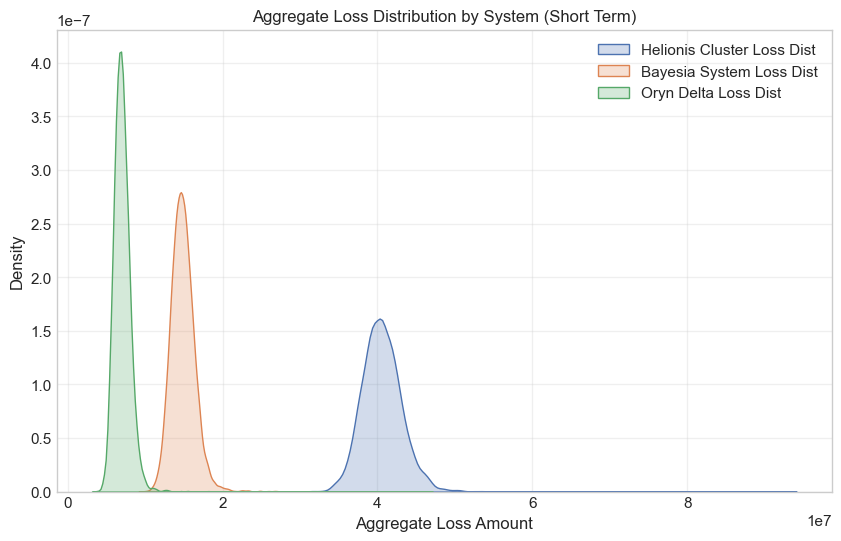

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import genpareto
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)

file_path = 'final_cleaned_equipment_data.xlsx'
df_sev_raw = pd.read_excel(file_path, sheet_name='sev')

THRESHOLD = 197906

df_body_all = df_sev_raw[df_sev_raw['claim_amount'] <= THRESHOLD].copy()
df_tail_all = df_sev_raw[df_sev_raw['claim_amount'] > THRESHOLD].copy()

# Fit GPD 
excess_loss = df_tail_all['claim_amount'] - THRESHOLD
shape, loc, scale_gpd = genpareto.fit(excess_loss)

global_tail_prob = len(df_tail_all) / len(df_sev_raw)

print("\n========== Global GPD Tail ==========")
print(f"Global Tail Prob = {global_tail_prob:.6f}")
print(f"Shape(xi) = {shape:.4f}")
print(f"Scale = {scale_gpd:.2f}")

# Base Parameters
systems = ['Helionis Cluster', 'Bayesia System', 'Oryn Delta']
system_multipliers = {
    'Helionis Cluster': 1.25,
    'Bayesia System': 1.35,
    'Oryn Delta': 1.45
}
profit_margin_rate = 0.05 
equipments = ['Quantum Bore', 'Graviton Extractor', 'FexStram Carrier', 
              'ReglAggregators', 'Flux Rider', 'Ion Pulverizer']
usage_data = {
    'Quantum Bore': {'Helionis Cluster': 0.95, 'Bayesia System': 0.80, 'Oryn Delta': 0.75},
    'Graviton Extractor': {'Helionis Cluster': 0.95, 'Bayesia System': 0.80, 'Oryn Delta': 0.75},
    'FexStram Carrier': {'Helionis Cluster': 0.90, 'Bayesia System': 0.75, 'Oryn Delta': 0.70},
    'ReglAggregators': {'Helionis Cluster': 0.80, 'Bayesia System': 0.75, 'Oryn Delta': 0.70},
    'Flux Rider': {'Helionis Cluster': 0.80, 'Bayesia System': 0.80, 'Oryn Delta': 0.75},
    'Ion Pulverizer': {'Helionis Cluster': 0.50, 'Bayesia System': 0.60, 'Oryn Delta': 0.50}
}
maint_data = {
    'Quantum Bore': {'Helionis Cluster': 750, 'Bayesia System': 600, 'Oryn Delta': 500},
    'Graviton Extractor': {'Helionis Cluster': 750, 'Bayesia System': 600, 'Oryn Delta': 500},
    'FexStram Carrier': {'Helionis Cluster': 375, 'Bayesia System': 400, 'Oryn Delta': 250},
    'ReglAggregators': {'Helionis Cluster': 1500, 'Bayesia System': 1000, 'Oryn Delta': 300},
    'Flux Rider': {'Helionis Cluster': 1500, 'Bayesia System': 1000, 'Oryn Delta': 300},
    'Ion Pulverizer': {'Helionis Cluster': 1000, 'Bayesia System': 750, 'Oryn Delta': 500}
}

risk_idx = {
    'Quantum Bore': [0.69, 0.77, 0.93],
    'Graviton Extractor': [0.48, 0.57, 0.73],
    'FexStram Carrier': [0.67, 0.71, 0.78],
    'ReglAggregators': [0.24, 0.26, 0.35],
    'Flux Rider': [0.24, 0.21, 0.20],
    'Ion Pulverizer': [0.64, 0.66, 0.75]
}

model_params = {
    'ReglAggregators': {'f_int': -2.0842, 'f_usage': 0.2148, 'f_maint': 0.1021, 'f_age_old': 0.6947, 'f_log_exp': 0.9503, 's_int': 11.2152, 's_usage': 0.1197, 'phi': 0.1962, 's_log_exp': 0.0238, 'empirical_mean_intensity': 1.0919},
    'Flux Rider': {'f_int': -1.3551, 'f_usage': 0.2728, 'f_maint': 0.1415, 'f_age_old': 0.9663, 'f_log_exp': 1.1206, 's_int': 10.9536, 's_usage': 0.1535, 'phi': 0.2447, 's_log_exp': 0.0221, 'empirical_mean_intensity': 1.1240},
    'Graviton Extractor': {'f_int': -1.7597, 'f_usage': 0.2580, 'f_maint': 0.1396, 'f_age_old': 0.5520, 'f_log_exp': 1.0006, 's_int': 11.2378, 's_usage': 0.1226, 'phi': 0.2213, 's_log_exp': 0.0921, 'empirical_mean_intensity': 1.0837},
    'Quantum Bore': {'f_int': -1.9837, 'f_usage': 0.1980, 'f_maint': 0.1237, 'f_age_old': 0.5895, 'f_log_exp': 1.0056, 's_int': 11.5358, 's_usage': 0.1155, 'phi': 0.1487, 's_log_exp': -0.0135, 'empirical_mean_intensity': 1.0612},
    'Ion Pulverizer': {'f_int': -1.6909, 'f_usage': 0.2086, 'f_maint': 0.1013, 'f_age_old': 0.3961, 'f_log_exp': 1.0760, 's_int': 11.2763, 's_usage': 0.1324, 'phi': 0.1998, 's_log_exp': 0.0327, 'empirical_mean_intensity': 1.0959},
    'FexStram Carrier': {'f_int': -1.3923, 'f_usage': 0.3079, 'f_maint': 0.1537, 'f_age_old': 0.3756, 'f_log_exp': 1.0420, 's_int': 10.7630, 's_usage': 0.1267, 'phi': 0.2530, 's_log_exp': -0.0041, 'empirical_mean_intensity': 1.0957}
}

init_counts = {
    'Quantum Bore': [300,150,100], 'Graviton Extractor':[240,120,80],
    'FexStram Carrier':[150,75,50], 'ReglAggregators':[300,150,100],
    'Flux Rider':[1500,750,500], 'Ion Pulverizer':[90,45,30]
}

growth_rates = {'Helionis Cluster':1.25,'Bayesia System':1.25,'Oryn Delta':1.15}

hist_inflation = [0.0377, 0.0232, 0.0148, 0.0108, 0.0022, 0.0071, 0.0155, 
                  0.0216, 0.0181, 0.0073, 0.0294, 0.0708, 0.0598, 0.0276, 0.0239]
expected_inflation = (np.prod([1 + r for r in hist_inflation])**(1/len(hist_inflation))) - 1
spot_rates = {'short': 0.0474, 'long': 0.0510}

def run_objective_simulation(n_sim=10000, inflation_stress=0, freq_multiplier=1.0, use_dependency=False):
    summary = {sys: {'short': {'total': {}, 'equipments': {}, 'all_paths': None},
                      'long': {'total': {}, 'equipments': {}, 'all_paths': None}}
               for sys in systems}
    shared_radiation = np.random.gamma(1/0.15, 0.15, n_sim)
    shared_debris = np.random.gamma(1/0.15, 0.15, n_sim)

    for s_idx, sys in enumerate(systems):
        multiplier = system_multipliers[sys]
        for term, years in [('short',1),('long',10)]:
            total_path_costs = np.zeros(n_sim)
            discount_rate = spot_rates[term]
            adj_inflation = expected_inflation + inflation_stress
            pv_adj_factor = (1 + adj_inflation) / (1 + discount_rate)

            if use_dependency:
                if sys == 'Helionis Cluster':
                    common_shocks = 0.1 * shared_radiation + 0.9 * shared_debris
                elif sys == 'Bayesia System':
                    common_shocks = 0.9 * shared_radiation + 0.1 * shared_debris
                elif sys == 'Oryn Delta':
                    common_shocks = 0.5 * shared_radiation + 0.5 * shared_debris
            else:
                common_shocks = np.ones(n_sim)

            eq_summaries = {}

            for eq in equipments:
                p = model_params[eq]
                u_base = usage_data[eq]['Helionis Cluster']
                u_std = (usage_data[eq][sys] - u_base) / 0.1
                m_std = ((maint_data[eq][sys] / maint_data[eq]['Helionis Cluster']) - 1) / 0.2
                risk_factor = risk_idx[eq][s_idx] / risk_idx[eq][0]
                count = init_counts[eq][s_idx] * (1 + (growth_rates[sys]-1)*years/10)
                age_factor = p['f_age_old']*(years/10)
                log_exp_val = np.log(1.0)
                logit = (p['f_int'] + age_factor + p['f_usage']*u_std + p['f_maint']*m_std + p['f_log_exp']*log_exp_val)
                freq_prob = 1/(1+np.exp(-logit))
                log_mu = p['s_int'] + p['s_usage']*u_std + p['s_log_exp']*log_exp_val
                mu = np.exp(log_mu) * (pv_adj_factor**years)

                eq_path_costs = np.zeros(n_sim)
                for i in range(n_sim):
                    effective_lambda = freq_prob * count * risk_factor * p['empirical_mean_intensity'] * freq_multiplier * common_shocks[i]
                    n_claims = np.random.poisson(effective_lambda)
                    if n_claims > 0:
                        path_loss = 0
                        for _ in range(n_claims):
                            if np.random.rand() < global_tail_prob:
                                path_loss += THRESHOLD + genpareto.rvs(c=shape, scale=scale_gpd)
                            else:
                                path_loss += np.random.gamma(1/p['phi'], mu*p['phi'])
                        eq_path_costs[i] = path_loss
                
                total_path_costs += eq_path_costs

                exp_cost_eq = np.mean(eq_path_costs)
                total_load_eq = exp_cost_eq * (multiplier - 1)
                premium_val = (exp_cost_eq + total_load_eq) / (1 - profit_margin_rate)
                eq_returns = np.full(n_sim, premium_val)
                eq_net_rev = eq_returns * profit_margin_rate
                
                eq_summaries[eq] = {
                    'Exp Cost': exp_cost_eq / count, 
                    'Var Cost': np.var(eq_path_costs / count), 
                    'VaR Cost': np.percentile(eq_path_costs / count, 99),
                    'Exp Ret': np.mean(eq_returns) / count, 
                    'Var Ret': np.var(eq_returns / count), 
                    'VaR Ret': np.percentile(eq_returns / count, 99),
                    'Exp Net': np.mean(eq_net_rev) / count, 
                    'Var Net': np.var(eq_net_rev / count), 
                    'VaR Net': np.percentile(eq_net_rev / count, 99)
                }

            total_exp_cost = np.mean(total_path_costs)
            total_load_agg = total_exp_cost * (multiplier - 1)
            total_premium = (total_exp_cost + total_load_agg) / (1 - profit_margin_rate)
            total_returns = np.full(n_sim, total_premium)
            total_net_rev = total_returns * profit_margin_rate
            
            summary[sys][term]['equipments'] = eq_summaries
            summary[sys][term]['all_paths'] = total_path_costs 
            summary[sys][term]['total'] = {
                'Exp Cost': total_exp_cost, 'Var Cost': np.var(total_path_costs), 'VaR Cost': np.percentile(total_path_costs, 99),
                'Exp Ret': np.mean(total_returns), 'Var Ret': np.var(total_returns), 'VaR Ret': np.percentile(total_returns, 99),
                'Exp Net': np.mean(total_net_rev), 'Var Net': np.var(total_net_rev), 'VaR Net': np.percentile(total_net_rev, 99),
                'TVaR 99%': total_path_costs[total_path_costs >= np.percentile(total_path_costs,99)].mean()
            }
    return summary
    
results = run_objective_simulation()

for term_key, term_name in [('short', 'Short Term (1 Year)'), ('long', 'Long Term (10 Years)')]:
    print(f"\n{'='*30} {term_name} Report {'='*30}")
    print(f"\n[System-Level Summary - Aggregate Data]")
    header = f"{'System':<20} | {'Exp Cost':>10} | {'Var Cost':>10} | {'VaR Cost':>10} | {'Exp Ret':>10} | {'Var Ret':>10} | {'VaR Ret':>10} | {'Exp Net':>10} | {'Var Net':>10} | {'VaR Net':>10}"
    print(header)
    for sys in systems:
        d = results[sys][term_key]['total']
        print(f"{sys:<20} | {d['Exp Cost']:>10,.0f} | {d['Var Cost']:>10.1e} | {d['VaR Cost']:>10,.0f} | {d['Exp Ret']:>10,.0f} | {d['Var Ret']:>10.1e} | {d['VaR Ret']:>10,.0f} | {d['Exp Net']:>10,.0f} | {d['Var Net']:>10.1e} | {d['VaR Net']:>10,.0f}")

    print(f"\n[Equipment-Level Detail - Average Per Unit Data]")
    for sys in systems:
        print(f"\n--- {sys} ---")
        for eq in equipments:
            d = results[sys][term_key]['equipments'][eq]
            print(f"{eq:<20} | Avg Cost: {d['Exp Cost']:>10,.0f} | Avg Ret: {d['Exp Ret']:>10,.0f} | Avg Net: {d['Exp Net']:>10,.0f}")

print(f"\n{'='*20} Tail Risk Analysis (TVaR 99% System Total) {'='*20}")
for sys in systems:
    print(f"- {sys}: Short Term {results[sys]['short']['total']['TVaR 99%']:,.0f} | Long Term {results[sys]['long']['total']['TVaR 99%']:,.0f}")

print(f"\n\n{'#'*60}\n# 3. Summary of Pricing and Capital Modeling\n{'#'*60}")

plt.figure(figsize=(10, 6))
for sys in systems:
    sns.kdeplot(results[sys]['short']['all_paths'], label=f'{sys} Loss Dist', fill=True)
plt.title("Aggregate Loss Distribution by System (Short Term)")
plt.xlabel("Aggregate Loss Amount")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
print(f"\n\n{'#'*60}\n# 4. Stress and Scenario Testing (n=2000)\n{'#'*60}")

stress_results = {
    "Baseline (Ref)": run_objective_simulation(n_sim=2000),
    "Freq Stress (+50%)": run_objective_simulation(n_sim=2000, freq_multiplier=1.5),
    "Inflation Stress (+5%)": run_objective_simulation(n_sim=2000, inflation_stress=0.05),
    "Dependency (Risk-Based)": run_objective_simulation(n_sim=2000, use_dependency=True),
    
    "Best-Case (Smooth Ops)": run_objective_simulation(n_sim=2000, freq_multiplier=0.8),
    "Moderate-Case (Batch Defect)": run_objective_simulation(n_sim=2000, freq_multiplier=1.3),
    "Worst-Case (Solar Flares)": run_objective_simulation(n_sim=2000, freq_multiplier=2.0, use_dependency=True)
}

stress_header = f"{'Scenario':<30} | {'Helionis VaR':>15} | {'Bayesia VaR':>15} | {'Oryn VaR':>15}"
print("-" * len(stress_header))
print(stress_header)
print("-" * len(stress_header))

for sc_name, sc_res in stress_results.items():
    v1 = sc_res['Helionis Cluster']['short']['total']['VaR Cost']
    v2 = sc_res['Bayesia System']['short']['total']['VaR Cost']
    v3 = sc_res['Oryn Delta']['short']['total']['VaR Cost']
    print(f"{sc_name:<30} | {v1:>15,.0f} | {v2:>15,.0f} | {v3:>15,.0f}")



############################################################
# 4. Stress and Scenario Testing (n=2000)
############################################################
------------------------------------------------------------------------------------
Scenario                       |    Helionis VaR |     Bayesia VaR |        Oryn VaR
------------------------------------------------------------------------------------
Baseline (Ref)                 |      46,841,225 |      18,808,033 |       9,716,719
Freq Stress (+50%)             |      71,841,497 |      27,126,315 |      14,136,756
Inflation Stress (+5%)         |      48,565,259 |      19,737,636 |      10,314,297
Dependency (Risk-Based)        |      85,118,848 |      31,104,545 |      13,177,898
Best-Case (Smooth Ops)         |      38,526,826 |      15,791,969 |       8,092,599
Moderate-Case (Batch Defect)   |      62,094,048 |      24,195,641 |      12,296,274
Worst-Case (Solar Flares)      |     168,109,180 |      59,129,826 | 